# Resolucion de Ecuaciones Diferenciales en Python

In [174]:
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.integrate import solve_ivp
%matplotlib inline

## ED de Primer Orden

In [175]:
tIni = 1
tFin = 10
nPuntos = 1000
ts = np.linspace(tIni,tFin,nPuntos)

In [176]:
def errorED(areaExacta,areaCalculada):
    return 100 * (areaExacta - areaCalculada) / areaExacta

### Metodo Integro a Capon el ln

In [177]:
def Euler(tIni, tFin,nPuntos, y_0,ts):
    h = (tFin - tIni)/nPuntos
    y = np.zeros(nPuntos)
    y[0] = y_0
    
    #Metodo Invertebrado
    for i in range(1,len(ts)):
        y[i] = y[i-1] + (h*(1/(ts[i-1])))

    return y 

In [178]:
integral = Euler(tIni,tFin,nPuntos,np.log(tIni),ts)

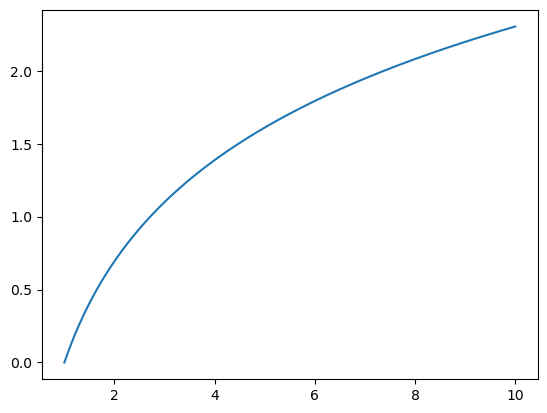

In [179]:
plt.plot(ts,y)
plt.show()

### Para cualquier funcion

In [180]:
def Euler(tIni, tFin,nPuntos,ts,f_x):
    h = (tFin - tIni)/nPuntos
    y = np.zeros(nPuntos)
    y[0] = f_x(tIni)
    
    #Metodo Invertebrado
    for i in range(1,len(ts)):
        y[i] = y[i-1] + (h*f_x(i-1))
    return y 

In [181]:
f_t = lambda x: np.cos(ts[x])
integral = Euler(tIni,tFin,nPuntos,ts,f_t)
errorEuler = errorED(np.sin(ts[1:]),integral[1:])

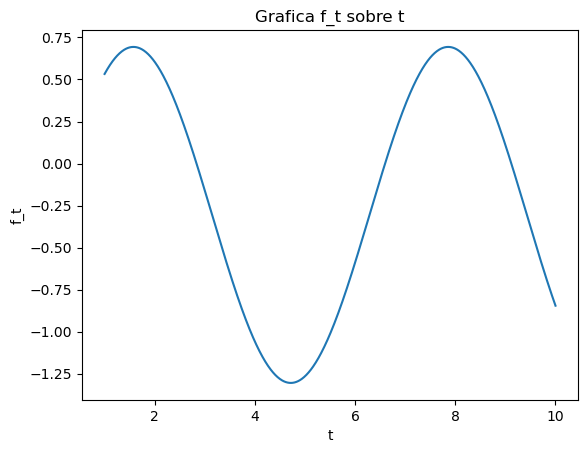

In [182]:
plt.title("Grafica f_t sobre t")
plt.xlabel("t")
plt.ylabel("f_t")
plt.plot(ts,integral)
plt.show()

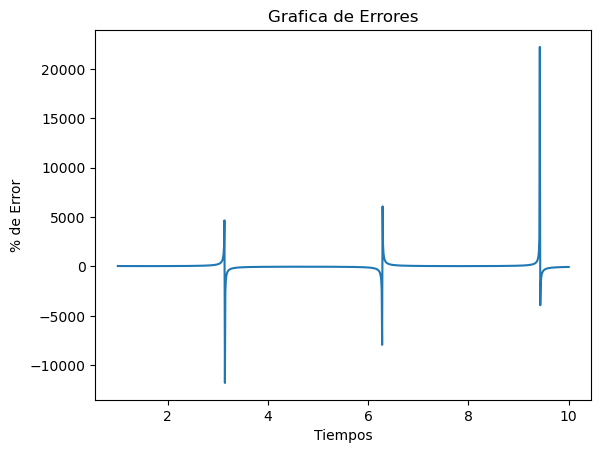

In [183]:
plt.title("Grafica de Errores")
plt.xlabel("Tiempos")
plt.ylabel("% de Error")
plt.plot(ts[1:],errorEuler)
plt.show()

### Usando Scipy
#### Para coseno

In [184]:
tIni = 2
tFin = 10
ts = np.linspace(tIni,tFin,nPuntos)
f_t = lambda t,y: np.cos(t);
y_0 = np.sin(tIni)
integralCos = solve_ivp(f_t, (tIni,tFin),[y_0],t_eval= ts)
errorScipyCos = abs(errorED(np.log(integralLn.t),integralLn.y[0]))

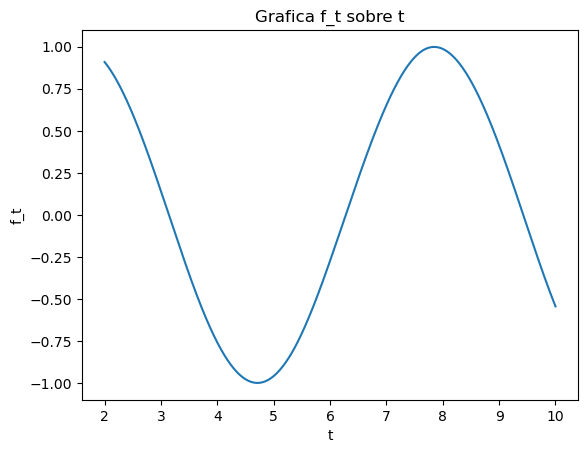

In [185]:
plt.title("Grafica f_t sobre t")
plt.xlabel("t")
plt.ylabel("f_t")
plt.plot(integralCos.t,integralCos.y[0])
plt.show()

### Con ln

In [186]:
tIni = 2
tFin = 10
ts = np.linspace(tIni,tFin,nPuntos)
f_t = lambda t,y: 1/t;
y_0 = np.log(tIni)
integralLn = solve_ivp(f_t, (tIni,tFin),[y_0],t_eval=ts)
errorScipyLn = abs(errorED(np.log(integralLn.t),integralLn.y[0]))

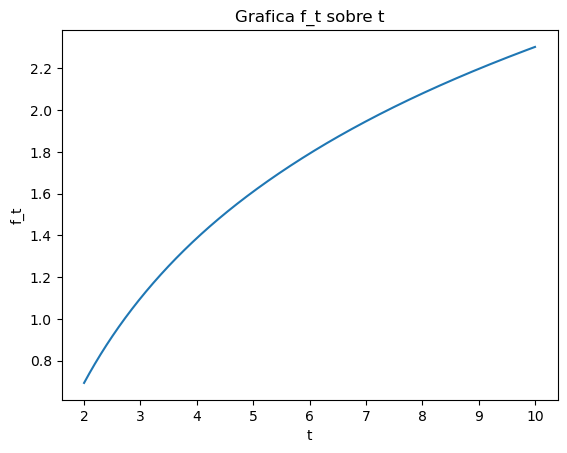

In [187]:
plt.title("Grafica f_t sobre t")
plt.xlabel("t")
plt.ylabel("f_t")
plt.plot(integralLn.t,integralLn.y[0])
plt.show()

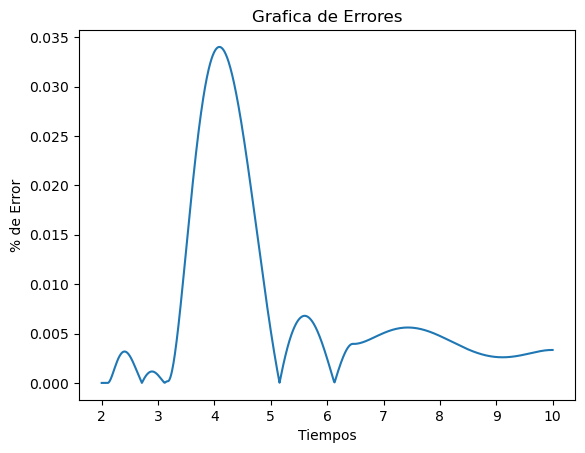

In [188]:
plt.title("Grafica de Errores")
plt.xlabel("Tiempos")
plt.ylabel("% de Error")
plt.plot(integralLn.t,errorScipyLn)
plt.show()

### Comparacion Scipy y Euler

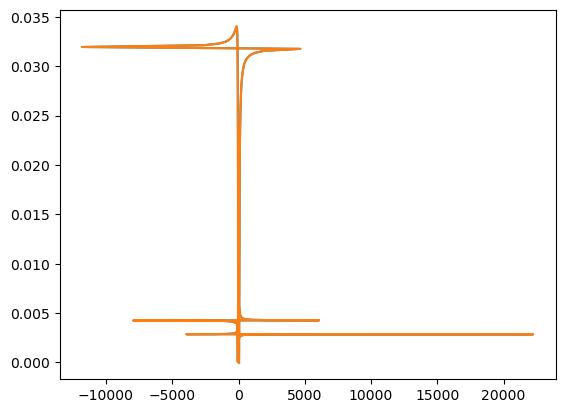

In [191]:
plt.plot(errorEuler,errorScipyCos[1:])
plt.show()

## EDO de Segundo Orden
### Oscilador Armonico Simple


In [ ]:
numPuntos = 1000
tIni = 0
tFin = 10
x_0 = 5
v_0 = 0
k = 1
m = 1
t= np.linspace(tIni,tFin,numPuntos-1)

In [ ]:
def OAS(t,x_0,v_0,k,m,np):
    x = [x_0]
    v = [v_0]
    h = t[1] - t[0]
    
    for i in range(1,np):
        v.append(v[i-1] - (h*(k/m)*x[i-1]))
        x.append(x[i-1] + h*v[i])

    return x,v

In [ ]:
x,v = OAS(t,x_0,v_0,k,m,nPuntos)

In [ ]:
plt.title("Desplazamiento sobre tiempo")
plt.xlabel("t")
plt.ylabel("x")
plt.plot(t,x)
plt.show()
